# Notes
### 16.03.2023
- some images of black men and deers were generating errors that were unable to track down as such those images were removed as a whole
- Total dataset as of 16.03.2023 contains ~1000 images of animals and ~3000 images of humans
- Working on whole dataset was too slow for testing so dataset used was reduced to: 
  1. 50 images per class
  2. 100 images per class
  3. 150 images per class*

  *had best resoults  
- transform learning is not generating satisfactory accuracy score
- Dense network has high peak of 70% accuracy on validation dataset however contains 100,811,649 parameters and generates 1.13GB hdf5 file
- CNN acheaves peak accuracy of 85% and loss of 0.4441 on validation dataset containing 99,041 parameters and generates 1.18MB hdf5 file

- CNN on 150 images acheaves peak accuracy of 83% and loss of 0.4051 on validation dataset containing 99,041

- Adding batch normalization layer stalled learning progress
### 17.03.2023
- Reconfigured translation learning and achived accuracy of 96.67% and loss of 0.0398 on vlaidation 

- Cleaned image dataset, 816 images of humans equaly split across races and genders, 820 images of animals equaly split across wolfs, deers, fox, wild boars

### 18.03.2023
- Trained CNN with 99k paramaters on dataset with 820 images pre class
- Trained transfer CNN on dataset with 820 images pre class

### 20.03.2023
- Added Grad-CAM heatmap
### 22.03.2023
- Added Noise data
### 23.03.2023
- Trying to improve accuracy with noise data
- Removed noise data
### 24.03.2023
- Trained a cnn with transfer learning
- Fixed problem with transfer learning
- Fixed problem with gradcam
- Created a gallery of gradcam with predicted values
- Cleaned code
- created subset from imsitu of "biking"
- added a picture of "biking" to training dataset
- network potentialy too big, gradcam has tiny points

In [1]:
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tqdm import tqdm
from PIL import Image as ImagePIL
import os, sys
import matplotlib
from IPython.display import Image, display

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

2023-03-31 16:22:35.902423: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-03-31 16:22:35.925273: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-03-31 16:22:35.925724: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-31 16:22:36.360125: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def loss_plotter(H):
    plt.figure()
    plt.plot(H.history['loss'])
    plt.plot(H.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()

    
def accuracy_plotter(H):
    # YOUR CODE HERE #
    plt.figure()
    plt.plot(H.history['accuracy'])
    plt.plot(H.history['val_accuracy'])
    # Make it pretty
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])
    plt.show()
    
    
def precision_plotter(H):
    
    plt.figure()
    plt.plot(H.history['precision'])
    plt.plot(H.history['val_precision'])
    
    plt.title('Model precision')
    plt.ylabel('precision')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])
    plt.show()

In [3]:
root_dir = "../data/"
sucess = 0
corrupt = 0
size = (256,256)
for filename in tqdm(glob.iglob(root_dir + '**/*.*', recursive=True)):
    try:
        im = ImagePIL.open(filename)
        imResize = im.resize((256, 256), ImagePIL.ANTIALIAS)
        imResize.save(filename , 'JPEG')
        imResize.verify()
        sucess += 1
        
    except (IOError, SyntaxError) as e:
        os.remove(filename)
        corrupt += 1
        
print("sucessful: " + str(sucess))
print("coruppted: " + str(corrupt))
    

1637it [00:00, 1952.52it/s]

sucessful: 1637
coruppted: 0


## 1) The Dataset

- Assuming you have a classification problem, is it binary, multi-class or multi-label? binary

- Show a few examples per class

- How many classes? 2

- How many images per class? 50

- Train/Test sizes 0.67/0.33

- Image size? 256x256

- How are the images labeled?

- Dataset source(s)? DuckDuckGo images

In [4]:
directory = '../data/'
image_size = (256, 256)
batch_size = 32
seed_train_validation = 64
validation_split = 0.3
color_mode = 'rgb'

'''
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/",
    validation_split=0.2,
    subset="both",
    seed=64,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="rgb"
)
'''

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory = directory,
    image_size = image_size,
    validation_split = validation_split,
    subset = "training",
    seed = seed_train_validation,
    color_mode = color_mode,
    shuffle = True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory = directory,
    image_size = image_size,
    validation_split = validation_split,
    subset = "validation",
    seed = seed_train_validation,
    color_mode = color_mode,
    shuffle = True
)

val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take((val_batches) // 3)
val_ds = val_ds.skip((val_batches) // 3)


Found 1640 files belonging to 2 classes.
Using 1148 files for training.
Found 1640 files belonging to 2 classes.
Using 492 files for validation.


2023-03-31 16:22:38.189377: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


2023-03-31 16:22:38.733511: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1148]
	 [[{{node Placeholder/_4}}]]
2023-03-31 16:22:38.733895: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1148]
	 [[{{node Placeholder/_4}}]]


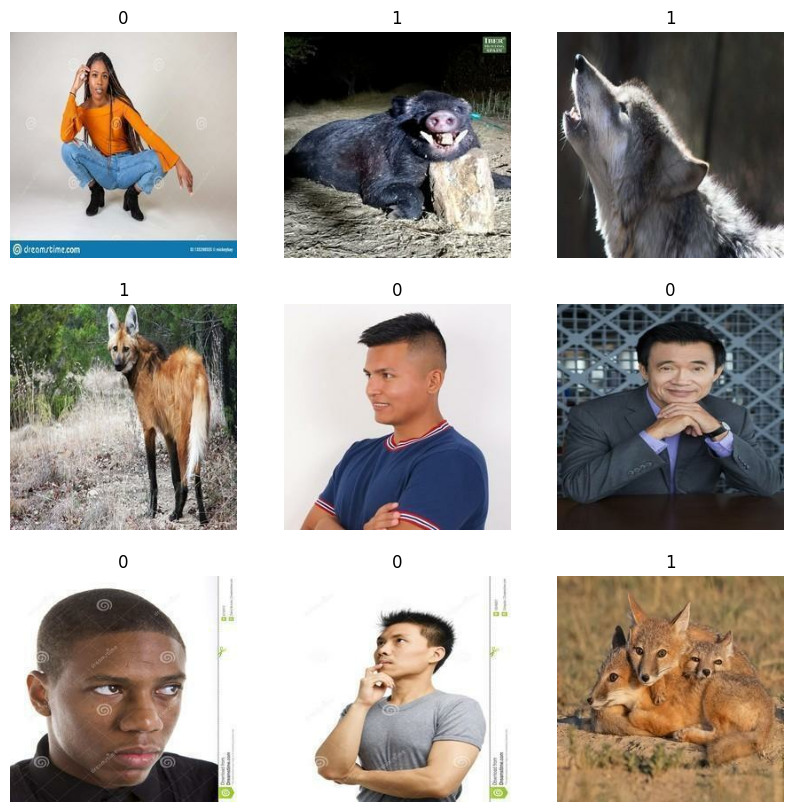

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

## 2) Baselines

- Random guess accuracy? 50%

- Human-Level Performance accuracy? 100%

- Multilayer Perceptron accuracy? 65%

In [6]:
inputs = tf.keras.Input(shape=(256,256,3))
x = layers.Flatten()(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, output)

In [7]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 flatten (Flatten)           (None, 196608)            0         
                                                                 
 rescaling (Rescaling)       (None, 196608)            0         
                                                                 
 dense (Dense)               (None, 512)               100663808 
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 64)                16448     
                                                                 
 dropout (Dropout)           (None, 64)                0     

In [8]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', tf.keras.metrics.Precision()])

monitor_val_acc = EarlyStopping(monitor='val_loss', 
                                patience=5,
                                min_delta=0.005,
                                restore_best_weights=True
                               )

model_checkpoint = ModelCheckpoint('../models/best_model_dense.hdf5', save_best_only = True)

In [9]:
h = model.fit(train_ds, epochs = 1000,
#                            batch_size = 32,
                            validation_data=val_ds,
                            callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000


2023-03-31 16:22:41.846198: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1148]
	 [[{{node Placeholder/_4}}]]
2023-03-31 16:22:41.846551: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1148]
	 [[{{node Placeholder/_0}}]]


36/36 [==============================] - ETA: 0s - loss: 23.3720 - accuracy: 0.5026 - precision: 0.5019

2023-03-31 16:23:20.315339: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [492]
	 [[{{node Placeholder/_4}}]]
2023-03-31 16:23:20.315537: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [492]
	 [[{{node Placeholder/_0}}]]


36/36 [==============================] - 48s 1s/step - loss: 23.3720 - accuracy: 0.5026 - precision: 0.5019 - val_loss: 2.0434 - val_accuracy: 0.5211 - val_precision: 1.0000
Epoch 2/1000
36/36 [==============================] - 47s 1s/step - loss: 1.3132 - accuracy: 0.5767 - precision: 0.5670 - val_loss: 0.6457 - val_accuracy: 0.5181 - val_precision: 0.5182
Epoch 3/1000
36/36 [==============================] - 38s 1s/step - loss: 0.6887 - accuracy: 0.5209 - precision: 0.5117 - val_loss: 0.7041 - val_accuracy: 0.5241 - val_precision: 0.5241
Epoch 4/1000
36/36 [==============================] - 47s 1s/step - loss: 0.6396 - accuracy: 0.6568 - precision: 0.6077 - val_loss: 0.6409 - val_accuracy: 0.6265 - val_precision: 0.5806
Epoch 5/1000
36/36 [==============================] - 48s 1s/step - loss: 0.6198 - accuracy: 0.7073 - precision: 0.6965 - val_loss: 0.6132 - val_accuracy: 0.6416 - val_precision: 0.8333
Epoch 6/1000
36/36 [==============================] - 48s 1s/step - loss: 0.5905 -

In [10]:
model.evaluate(test_ds)

2/5 [===========>..................] - ETA: 0s - loss: 0.5246 - accuracy: 0.7188 - precision: 0.7188

2023-03-31 16:33:34.304369: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [492]
	 [[{{node Placeholder/_0}}]]
2023-03-31 16:33:34.304559: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [492]
	 [[{{node Placeholder/_4}}]]


5/5 [==============================] - 0s 64ms/step - loss: 0.5258 - accuracy: 0.7250 - precision: 0.7260


[0.5258319973945618, 0.7250000238418579, 0.7260273694992065]

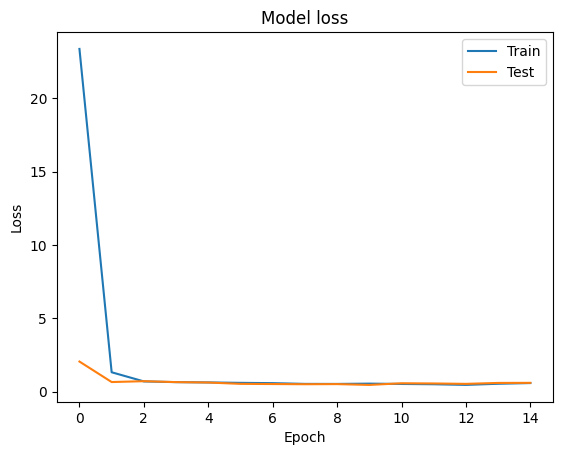

In [11]:
loss_plotter(h)

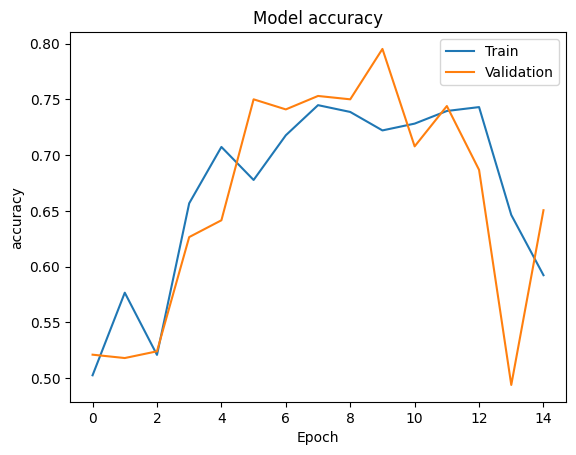

In [12]:
accuracy_plotter(h)

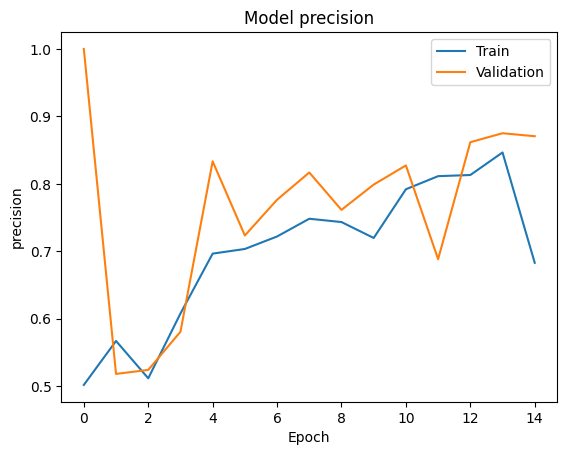

In [13]:
precision_plotter(h)

## 3) Preprocessing

Remove coruppted images,
resize all images to 256px by 256px

## 4) CNN architecture

In [12]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1)
    ]
)


In [13]:
base_model = keras.applications.Xception(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(256, 256, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.
base_model.trainable = False

inputs = keras.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)  # Apply random data augmentation

scale_layer = layers.Rescaling(1./255)
x = scale_layer(x)
x = base_model(x, training=False)
x = layers.Conv2D(128, kernel_size=3, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(64, 3, padding="same", activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(32, 3, padding="same", activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(16, 3, padding="same", activation='relu')(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 256, 256, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 256, 256, 3)       0         
                                                                 
 xception (Functional)       (None, 8, 8, 2048)        20861480  
                                                                 
 conv2d_4 (Conv2D)           (None, 6, 6, 128)         2359424   
                                                                 
 batch_normalization_4 (Batc  (None, 6, 6, 128)        512       
 hNormalization)                                                 
                                                             

## 5) CNN training

- Loss function

- Optimizer (with its hyper-parameters)

- Metrics

- Learning curves

In [14]:
model.compile('adam', 'binary_crossentropy', metrics=['accuracy',tf.keras.metrics.Precision()])

monitor_val_acc = tf.keras.callbacks.EarlyStopping(monitor='val_loss', 
                                                   patience=5,
                                                   mode='auto',
                                                   restore_best_weights=True,
                                                   min_delta=0.005
                                                  )

model_checkpoint = tf.keras.callbacks.ModelCheckpoint('../models/test.hdf5', save_best_only = True)

In [15]:
h = model.fit(train_ds, validation_data = val_ds, epochs = 1000, callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000


2023-03-31 13:30:35.306454: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1148]
	 [[{{node Placeholder/_4}}]]
2023-03-31 13:30:35.306934: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1148]
	 [[{{node Placeholder/_4}}]]


36/36 [==============================] - ETA: 0s - loss: 0.2722 - accuracy: 0.9739 - precision: 0.9772

2023-03-31 13:31:19.501526: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [492]
	 [[{{node Placeholder/_4}}]]
2023-03-31 13:31:19.501749: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [492]
	 [[{{node Placeholder/_0}}]]


36/36 [==============================] - 56s 2s/step - loss: 0.2722 - accuracy: 0.9739 - precision: 0.9772 - val_loss: 0.0849 - val_accuracy: 0.9819 - val_precision: 0.9663
Epoch 2/1000
36/36 [==============================] - 53s 1s/step - loss: 0.0579 - accuracy: 0.9965 - precision: 0.9982 - val_loss: 0.0332 - val_accuracy: 1.0000 - val_precision: 1.0000
Epoch 3/1000
36/36 [==============================] - 54s 2s/step - loss: 0.0245 - accuracy: 0.9991 - precision: 0.9983 - val_loss: 0.0182 - val_accuracy: 1.0000 - val_precision: 1.0000
Epoch 4/1000
36/36 [==============================] - 54s 2s/step - loss: 0.0138 - accuracy: 1.0000 - precision: 1.0000 - val_loss: 0.0154 - val_accuracy: 1.0000 - val_precision: 1.0000
Epoch 5/1000
36/36 [==============================] - 54s 2s/step - loss: 0.0095 - accuracy: 0.9965 - precision: 0.9948 - val_loss: 0.0474 - val_accuracy: 0.9789 - val_precision: 1.0000
Epoch 6/1000
36/36 [==============================] - 55s 2s/step - loss: 0.0135 - 

## 6) Model performance

Metrics plots

In [18]:
model.evaluate(test_ds)

2023-03-31 13:46:45.556237: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [492]
	 [[{{node Placeholder/_4}}]]
2023-03-31 13:46:45.556433: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [492]
	 [[{{node Placeholder/_4}}]]


5/5 [==============================] - 6s 1s/step - loss: 7.9993e-04 - accuracy: 1.0000 - precision: 1.0000


[0.0007999265799298882, 1.0, 1.0]

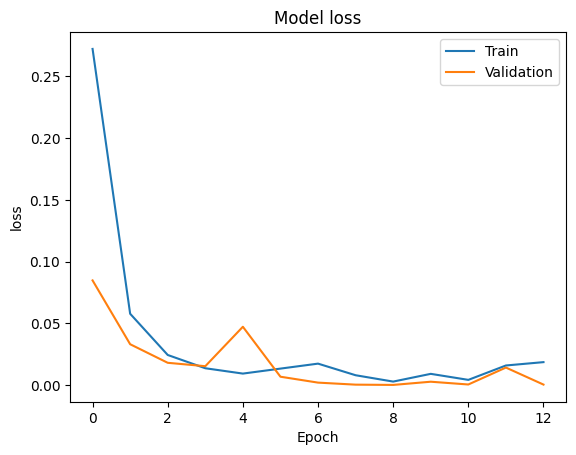

In [34]:
loss_plotter(h)

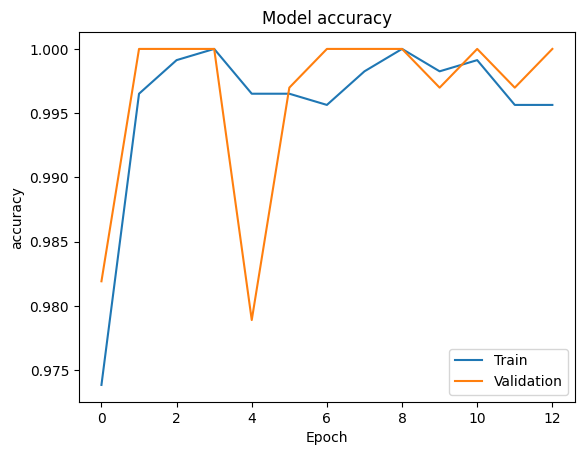

In [35]:
accuracy_plotter(h)

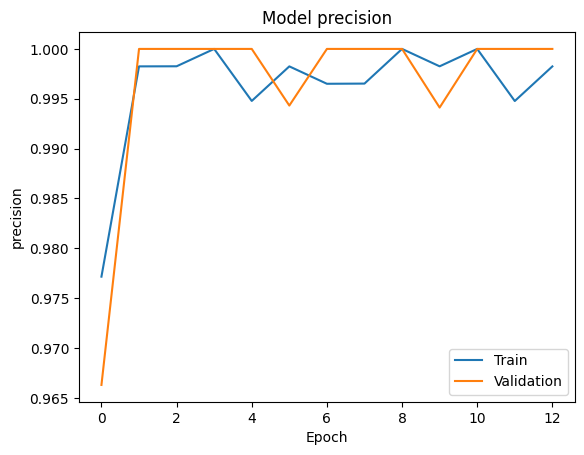

In [36]:
precision_plotter(h)

## 7) Error analysis

Top error interpretation

In [24]:
def get_img_array(img_path, size):
    # `img` is a PIL image of size 299x299
    img = keras.preprocessing.image.load_img(img_path, target_size=size)
    # `array` is a float32 Numpy array of shape (299, 299, 3)
    array = keras.preprocessing.image.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size (1, 299, 299, 3)
    array = np.expand_dims(array, axis=0)
    return array


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    # Load the original image
    img = keras.preprocessing.image.load_img(img_path)
    img = keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = matplotlib.colormaps['jet'] #cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
    display(Image(cam_path))


#### Heatmap for cnn

In [41]:
#model = keras.models.load_model('../models/best_model_cnn_99k_full_170323_0.hdf5', compile=False)
model = keras.models.load_model('../models/test.hdf5', compile=False)
model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])

In [25]:
root_dir = "../testdata/"
sucess = 0
corrupt = 0
img_size = (256,256)
for filename in tqdm(glob.iglob(root_dir + '**/*.*', recursive=True)):
    try:
        im = ImagePIL.open(filename)
        imResize = im.resize(img_size, ImagePIL.ANTIALIAS)
        imResize.save(filename , 'JPEG')
        imResize.verify()
        sucess += 1
        
    except (IOError, SyntaxError) as e:
        os.remove(filename)
        corrupt += 1
        
print("sucessful: " + str(sucess))
print("coruppted: " + str(corrupt))

10it [00:00, 44.33it/s]

sucessful: 10
coruppted: 0


In [27]:
last_conv_layer_name = 'conv2d_7'
img_path = "../testdata/8.jpg"
#img_path = "../data/1 - animal/003142d190664bf5a27472bc058a9295.jpg"
#img_path = "../data/0 - human/00dacc6df63040cb9d80b37a45679948.jpg"

img = keras.preprocessing.image.load_img(img_path)
#display(Image(img_path))

img_array = get_img_array(img_path, size=img_size)
# Print what the top predicted class is
preds = model.predict(img_array)
#print(f"Predicted: {100 * float(preds[0][0]):.2f}% a, {100 * float(preds[0][1]):.2f}% b, {100 * float(preds[0][2]):.2f}% c")
print(f"Predicted: {100 * float(preds[0]):.2f}% human")
# Generate class activation heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
#save_and_display_gradcam(img_path, heatmap)


1/1 [==============================] - 0s 44ms/step
Predicted: 100.00% human


1/1 [==============================] - 0s 46ms/step


2023-03-31 15:10:27.855909: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [492]
	 [[{{node Placeholder/_4}}]]
2023-03-31 15:10:27.856114: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [492]
	 [[{{node Placeholder/_4}}]]


1/1 [==============================] - 0s 46ms/step


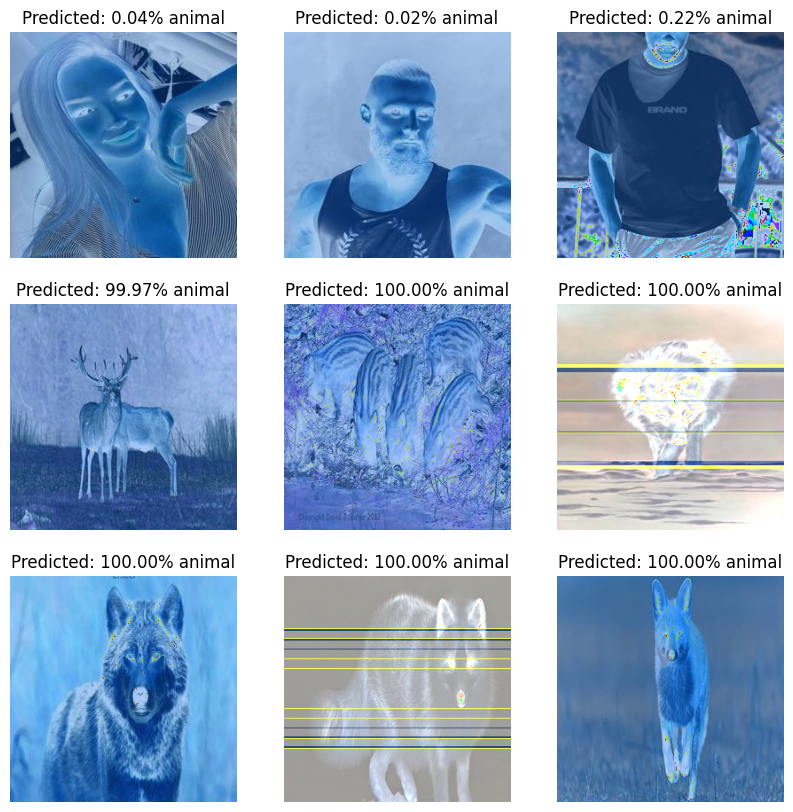

In [51]:
from tf_explain.core.grad_cam import GradCAM
explainer = GradCAM()
for images, labels in test_ds.take(1):
    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
    for i, ax in enumerate(axs.flat):
        ax.imshow(images[i].numpy().astype("uint8"))
        
        array = keras.preprocessing.image.img_to_array(images[i])
        array = np.expand_dims(array, axis=0)
        preds = model.predict(array)
        ax.set_title(f"Predicted: {100 * float(preds[0]):.2f}% animal")
        
        img = tf.keras.preprocessing.image.img_to_array(images[i])
        data = ([img], None)
        output = explainer.explain(data, model, 0, colormap=17)
        explainer.save(output, './', 'cam.jpg')
        
        ax.imshow(output)
        ax.axis("off")